In [1]:
import pandas as pd
import numpy as np
import kagglehub

In [2]:
path = kagglehub.dataset_download("disham993/9000-movies-dataset")
movies = pd.read_csv(path + "/mymoviedb.csv", engine='python')

100%|██████████| 1.70M/1.70M [00:01<00:00, 1.59MB/s]

Extracting files...


In [3]:
movies

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


In [4]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [5]:
movies = movies.dropna(subset=["Title", "Genre", "Overview"]).copy()
movies = movies.drop_duplicates(subset="Title").reset_index(drop=True)
movies["Genre"]    = movies["Genre"].fillna("")
movies["Overview"] = movies["Overview"].fillna("")

In [6]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9512 entries, 0 to 9511
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9512 non-null   object 
 1   Title              9512 non-null   object 
 2   Overview           9512 non-null   object 
 3   Popularity         9512 non-null   float64
 4   Vote_Count         9512 non-null   object 
 5   Vote_Average       9512 non-null   object 
 6   Original_Language  9512 non-null   object 
 7   Genre              9512 non-null   object 
 8   Poster_Url         9512 non-null   object 
dtypes: float64(1), object(8)
memory usage: 668.9+ KB


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# 1. „soup”: genul (cu virgulele scoase) + overview
movies["soup"] = movies["Genre"].str.replace(",", " ", regex=False) + " " + movies["Overview"]

# 2. matricea TF-IDF (fiecare film = un vector rar de termeni ponderati)
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf.fit_transform(movies["soup"])
print("Matrice TF-IDF:", tfidf_matrix.shape)

# 3. similaritatea cosinus intre toate filmele
#    (linear_kernel == cosinus pe vectori TF-IDF, care sunt deja normalizati L2)
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

# index rapid titlu -> pozitie
indices = pd.Series(movies.index, index=movies["Title"]).drop_duplicates()

Matrice TF-IDF: (9512, 5000)


In [8]:
def recommend_content_based(title, n=10):
    """Returneaza cele mai similare n filme cu `title`, pe baza continutului."""
    if title not in indices:
        return f"Filmul '{title}' nu a fost gasit."
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]          # sarim primul (filmul cu el insusi)
    movie_idx  = [i for i, _ in sim_scores]
    result = movies.iloc[movie_idx][["Title", "Genre", "Vote_Average"]].copy()
    result["similarity"] = [round(s, 3) for _, s in sim_scores]
    return result.reset_index(drop=True)

In [9]:
exemplu = movies["Title"].iloc[0]
print("Recomandari pentru:", exemplu, "\n")
recommend_content_based(exemplu, 10)

Recomandari pentru: Spider-Man: No Way Home 



,Title,Genre,Vote_Average,similarity
0,Spider-Man,"Fantasy, Action",7.2,0.290
1,Spider-Man: Into the Spider-Verse,"Action, Adventure, Animation, Science Fiction",8.4,0.272
2,Spider-Man Strikes Back,"Action, Adventure, Family, Fantasy, TV Movie",5.2,0.243
3,The Amazing Spider-Man,"Action, Adventure, Fantasy",6.7,0.227
4,Spider-Man: Homecoming,"Action, Adventure, Science Fiction, Drama",7.4,0.226
5,Spider-Man: Far From Home,"Action, Adventure, Science Fiction",7.5,0.223
6,Spider-Man 3,"Fantasy, Action, Adventure",6.3,0.220
7,The Amazing Spider-Man 2,"Action, Adventure, Fantasy",6.5,0.216
8,Peter's To-Do List,"Science Fiction, Comedy",7.1,0.212
9,Spider-Man 2,"Action, Adventure, Fantasy",7.2,0.199


In [10]:
# ---- Sintetizarea rating-urilor utilizator × film ----
np.random.seed(42)
N_USERS = 300

# lucram pe cele mai populare 500 de filme (matrice mai densa, mai relevanta)
top = movies.sort_values("Popularity", ascending=False).head(500).reset_index(drop=True)
N_ITEMS = len(top)

# codificam genul fiecarui film ca vector binar
all_genres = sorted({g.strip() for gs in top["Genre"] for g in gs.split(",")})
gidx = {g: i for i, g in enumerate(all_genres)}
item_genre = np.zeros((N_ITEMS, len(all_genres)))
for r, gs in enumerate(top["Genre"]):
    for g in gs.split(","):
        item_genre[r, gidx[g.strip()]] = 1

# fiecare utilizator = un vector de preferinte pe genuri
user_pref = np.random.normal(0, 1, (N_USERS, len(all_genres)))

# generam rating-uri 1..5 corelate cu potrivirea utilizator-gen
rows = []
for u in range(N_USERS):
    k = np.random.randint(15, 40)                       # cate filme a vazut
    for it in np.random.choice(N_ITEMS, k, replace=False):
        affinity = user_pref[u] @ item_genre[it] / (item_genre[it].sum() + 1e-9)
        score = 3 + affinity + np.random.normal(0, 0.6)
        rating = int(np.clip(round(score), 1, 5))
        rows.append((u, it, rating))

ratings = pd.DataFrame(rows, columns=["user", "item", "rating"])
sparsity = 100 * len(ratings) / (N_USERS * N_ITEMS)
print(f"{len(ratings)} rating-uri  |  {N_USERS} utilizatori × {N_ITEMS} filme  |  densitate {sparsity:.2f}%")
ratings.head()

7819 rating-uri  |  300 utilizatori × 500 filme  |  densitate 5.21%


,user,item,rating
0,0,380,3
1,0,109,4
2,0,432,4
3,0,92,3
4,0,4,4


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

# matricea utilizator × film (NaN = nevazut)
R = ratings.pivot_table(index="user", columns="item", values="rating")

# similaritatea intre filme, pe baza tiparelor de rating (nu a continutului!)
R_filled = R.fillna(0).values
item_sim = cosine_similarity(R_filled.T)
np.fill_diagonal(item_sim, 0)          # un film nu se recomanda pe sine
print("Matrice de similaritate intre filme:", item_sim.shape)

Matrice de similaritate intre filme: (500, 500)


In [12]:
def recommend_cf_item_based(user_id, n=10):
    """Recomanda filme pentru un utilizator, agregand similaritatile item-based."""
    user_ratings = np.nan_to_num(R.loc[user_id].values)
    scores = item_sim @ user_ratings
    norm   = np.abs(item_sim).sum(axis=1) + 1e-9
    pred   = scores / norm

    seen = np.where(~np.isnan(R.loc[user_id].values))[0]
    pred[seen] = -np.inf                # nu recomandam filme deja vazute

    best = np.argsort(pred)[::-1][:n]
    cols = R.columns[best]
    out = top.iloc[cols][["Title", "Genre", "Vote_Average"]].copy()
    out["pred_score"] = np.round(pred[best], 3)
    return out.reset_index(drop=True)


In [13]:
print("Filme deja evaluate de utilizatorul 0:")
seen_items = R.columns[~R.loc[0].isna()]
display(top.iloc[seen_items][["Title", "Genre"]].head(8))

print("\nRecomandari collaborative filtering pentru utilizatorul 0:")
recommend_cf_item_based(0, 10)

Filme deja evaluate de utilizatorul 0:


,Title,Genre
4,The King's Man,"Action, Adventure, Thriller, War"
5,The Commando,"Action, Crime, Thriller"
14,The Ice Age Adventures of Buck Wild,"Animation, Comedy, Adventure, Family"
35,Through My Window,"Romance, Drama"
39,Chernobyl: Abyss,"Drama, History, Adventure"
65,After We Fell,"Romance, Drama"
75,F9,"Action, Crime, Thriller, Adventure"
91,Heart Shot,"Romance, Crime"



Recomandari collaborative filtering pentru utilizatorul 0:


,Title,Genre,Vote_Average,pred_score
0,UFO,"Drama, Romance",5.2,0.320
1,Frozen,"Animation, Family, Adventure, Fantasy",7.3,0.315
2,Descendants: The Royal Wedding,"TV Movie, Animation, Comedy, Family, Drama",7.0,0.313
3,Fast & Furious Presents: Hobbs & Shaw,"Action, Adventure, Comedy",6.9,0.311
4,Snake Eyes: G.I. Joe Origins,"Action, Adventure",6.8,0.310
5,Rogue Hostage,"Action, Thriller",6.2,0.290
6,Luca,"Animation, Comedy, Family, Fantasy",8.0,0.283
7,Thor,"Adventure, Fantasy, Action",6.8,0.282
8,Death on the Nile,"Mystery, Crime, Drama, Thriller",6.7,0.280
9,Hotel Transylvania: Transformania,"Animation, Family, Fantasy, Comedy, Adventure",7.0,0.276


In [14]:
class MatrixFactorization:
    def __init__(self, n_users, n_items, k=20, lr=0.01, reg=0.1, epochs=40):
        self.n_users, self.n_items = n_users, n_items
        self.k, self.lr, self.reg, self.epochs = k, lr, reg, epochs

    def fit(self, data, verbose=True):
        # initializare aleatorie mica (rupe simetria)
        self.P  = np.random.normal(0, 0.1, (self.n_users, self.k))
        self.Q  = np.random.normal(0, 0.1, (self.n_items, self.k))
        self.bu = np.zeros(self.n_users)
        self.bi = np.zeros(self.n_items)
        self.mu = data["rating"].mean()          # media globala

        arr = data[["user", "item", "rating"]].values.copy()
        self.history = []
        for ep in range(self.epochs):
            np.random.shuffle(arr)
            sq_err = 0.0
            for u, i, r in arr:
                u, i = int(u), int(i)
                pred = self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i]
                e = r - pred
                sq_err += e * e
                # actualizari SGD
                self.bu[u] += self.lr * (e - self.reg * self.bu[u])
                self.bi[i] += self.lr * (e - self.reg * self.bi[i])
                pu = self.P[u].copy()
                self.P[u] += self.lr * (e * self.Q[i] - self.reg * self.P[u])
                self.Q[i] += self.lr * (e * pu       - self.reg * self.Q[i])
            rmse = np.sqrt(sq_err / len(arr))
            self.history.append(rmse)
            if verbose and (ep % 5 == 0 or ep == self.epochs - 1):
                print(f"Epoca {ep:2d}  RMSE={rmse:.4f}")
        return self

    def predict(self, u, i):
        return self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i]

In [15]:
mf = MatrixFactorization(N_USERS, N_ITEMS, k=20, lr=0.01, reg=0.1, epochs=40)
mf.fit(ratings)

Epoca  0  RMSE=0.9008
Epoca  5  RMSE=0.8276
Epoca 10  RMSE=0.8079
Epoca 15  RMSE=0.7934
Epoca 20  RMSE=0.7771
Epoca 25  RMSE=0.7564
Epoca 30  RMSE=0.7302
Epoca 35  RMSE=0.6986
Epoca 39  RMSE=0.6701


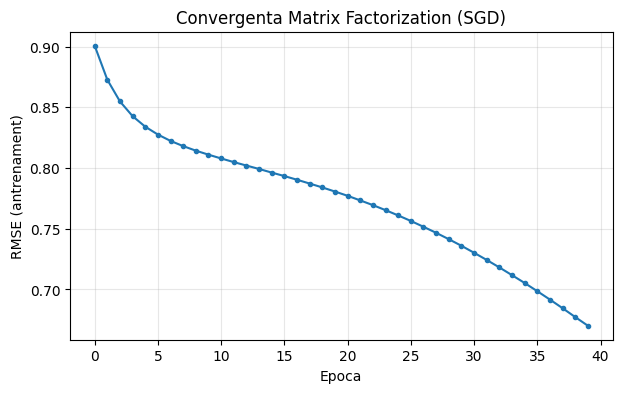

In [16]:
# curba de invatare — RMSE trebuie sa scada spre convergenta
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
plt.plot(mf.history, marker="o", ms=3)
plt.xlabel("Epoca"); plt.ylabel("RMSE (antrenament)")
plt.title("Convergenta Matrix Factorization (SGD)")
plt.grid(alpha=0.3); plt.show()

In [17]:
def recommend_mf(user_id, n=10):
    """Recomanda filme prezicand rating-ul pentru fiecare film nevazut."""
    seen = set(ratings[ratings.user == user_id]["item"])
    preds = [(i, mf.predict(user_id, i)) for i in range(N_ITEMS) if i not in seen]
    preds.sort(key=lambda x: x[1], reverse=True)
    best_idx = [i for i, _ in preds[:n]]
    out = top.iloc[best_idx][["Title", "Genre", "Vote_Average"]].copy()
    out["pred_rating"] = [round(mf.predict(user_id, i), 2) for i in best_idx]
    return out.reset_index(drop=True)

In [18]:
print("Recomandari Matrix Factorization pentru utilizatorul 0:")
recommend_mf(0, 10)

Recomandari Matrix Factorization pentru utilizatorul 0:


,Title,Genre,Vote_Average,pred_rating
0,Forgive Us Our Trespasses,"Drama, War",6.3,3.98
1,Voyagers,"Science Fiction, Thriller",6.2,3.96
2,The Pilgrim's Progress,"Animation, Adventure",7.9,3.86
3,Nobody,"Action, Crime, Thriller",8.2,3.82
4,Fight Club,Drama,8.4,3.77
5,American Siege,"Action, Thriller, Crime, Drama",5.4,3.74
6,Morbius,"Action, Science Fiction, Fantasy",0.0,3.74
7,The Deep House,Horror,6.5,3.74
8,Spiral: From the Book of Saw,"Horror, Crime, Mystery",6.2,3.74
9,Matando Cabos 2: La Máscara del Máscara,"Action, Comedy, Adventure",7.8,3.74
